# Train U-Net landuse segmentation (fond / parking / industriel / friche / residentiel)

Trains on the tiles produced by `fetch_landuse_dataset.ipynb`. Resumes the attempt halted
in `docs/roadmap_segmentation.md` (read it first), applying its priority fix #1: a
**class-weighted loss** (Dice + weighted CrossEntropy) to counter the extreme pixel
imbalance that made the first attempt's IoU collapse to ~0 on parking/friche. Fix #2
(multiple AOIs instead of one) is handled upstream by the fetch notebook.

Also adds a 5th class, **residentiel**, not in the original roadmap: without it, residential
areas had no correct bucket and the model was routing them into parking/friche instead
(visually ambiguous with those classes at 10m/pixel Sentinel-2 resolution).

**Run `fetch_landuse_dataset.ipynb` first** — this notebook expects tiles in `data/landuse/{images,masks}`,
regenerated with the residential class burned into the masks.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import torch
from torch.utils.data import DataLoader, Subset, random_split

from helpers.mask_rasterize import CLASS_NAMES, colorize_mask
from helpers.segmentation_dataset import SegmentationTileDataset, compute_class_pixel_weights
from models.unet_builder import build_unet
from training.pipeline_configs import UNET_CONFIG
from training.seg_engine import SegEngine

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Classes ({UNET_CONFIG.num_classes}): {CLASS_NAMES}")

Using device: mps
Classes (5): ['Fond', 'Parking', 'Industriel/commercial', 'Friche', 'Residentiel']


### 1/ Load the tile dataset

In [2]:
DATA_DIR = Path.cwd().parent / "data" / "landuse"

full_dataset = SegmentationTileDataset(DATA_DIR / "images", DATA_DIR / "masks")
# Same tiles, same filename order -- only difference is augment=True. Used for the train
# split below so train gets random flip/rotation augmentation while val/test stay on the
# clean `full_dataset` instance (stable, comparable metrics across epochs/folds).
full_dataset_augmented = SegmentationTileDataset(DATA_DIR / "images", DATA_DIR / "masks", augment=True)
print(f"{len(full_dataset)} tiles")

if len(full_dataset) == 0:
    raise RuntimeError("No tiles found -- run fetch_landuse_dataset.ipynb first.")

1097 tiles


### 2/ Split into train / val / test

Train reads from `full_dataset_augmented` (random flip/90-degree-rotation augmentation),
val/test read from the clean `full_dataset` -- same indices, different underlying instance
per split. Random split (not grouped) here on purpose: this is the fast day-to-day loop,
section 10 below has the grouped-by-AOI version for a more honest generalization check.

In [3]:
BATCH_SIZE = 8
SEED_NUM = 42

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
generator = torch.Generator().manual_seed(SEED_NUM)
train_subset, val_subset, test_subset = random_split(full_dataset, [train_size, val_size, test_size], generator=generator)

# Train loader reads the same indices from the *augmented* dataset instance.
train_subset_aug = Subset(full_dataset_augmented, train_subset.indices)

train_loader = DataLoader(train_subset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"train={len(train_subset)} val={len(val_subset)} test={len(test_subset)}")

train=767 val=164 test=166


### 3/ Class weights (fix #1 from the roadmap)

Inverse pixel-frequency weights computed on the **train split only**. Fond will end up
near-1, parking/friche should end up with the largest weights since they're by far the
rarest classes (see docs/roadmap_segmentation.md §5 for the baseline numbers).

In [4]:
class_weights = compute_class_pixel_weights(train_subset, num_classes=UNET_CONFIG.num_classes)
for name, w in zip(CLASS_NAMES, class_weights.tolist()):
    print(f"  {name}: {w:.3f}")

  Fond: 0.238
  Parking: 58.462
  Industriel/commercial: 6.561
  Friche: 18.798
  Residentiel: 1.755


### 4/ Build the U-Net and the training engine

In [6]:
model = build_unet(num_classes=UNET_CONFIG.num_classes, device=device)
optimizer = torch.optim.Adam(model.parameters(), lr=UNET_CONFIG.lr)
engine = SegEngine(device, optimizer, num_classes=UNET_CONFIG.num_classes, class_weights=class_weights)
engine.display_info()

device: mps, num_classes: 5, ce weight: tensor([ 0.2377, 58.4615,  6.5612, 18.7981,  1.7548], device='mps:0'), optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


### 5/ Train

`PATIENCE` : arrête l'entraînement si `val_mean_iou` n'a pas battu son record depuis
`PATIENCE` epochs -- `EPOCHS` (100, voir `UNET_CONFIG`) n'est plus qu'un plafond de
sécurité. Relevée de 10 à 20 : avec 17 AOI très hétérogènes géographiquement, le val mean
IoU oscille sans tendance claire sur 20 epochs (best epoch bloqué à 10 dans deux runs
d'affilée, avec le train loss qui continue pourtant de baisser) -- 10 epochs de patience
coupait probablement avant qu'un vrai plateau ait eu le temps de se dégager du bruit.

In [7]:
EPOCHS = UNET_CONFIG.epochs
PATIENCE = 20

history = engine.train_model(model, train_loader, val_loader, EPOCHS, class_names=CLASS_NAMES, patience=PATIENCE)

KeyboardInterrupt: 

### 5bis/ Recharger les poids du meilleur epoch

Le val loss ci-dessus baisse puis remonte après quelques epochs pendant que le train loss
continue de baisser -- overfitting classique sur un dataset de cette taille. `model`
contient à ce stade les poids de la *dernière* epoch, pas les meilleurs. `engine` a gardé
une copie des poids de l'epoch au **val mean IoU le plus haut** (`engine.best_state_dict`)
-- pas au val loss le plus bas : les deux ne bougent pas ensemble ici (le val loss est
dominé par le volume de pixels de Fond même pondéré, alors qu'une epoch peut avoir un val
loss moins bon mais mieux détecter les classes rares) -- on les recharge dans `model` ici,
avant les sections 7/8/9, pour que le test set, les visualisations et le checkpoint
sauvegardé portent tous sur le même modèle (le meilleur, pas le plus overfit).

In [7]:
print(f"Meilleure epoch: {engine.best_epoch}/{EPOCHS} (val mean IoU={engine.best_mean_iou:.4f}, val loss={engine.best_val_loss:.4f})")
model.load_state_dict(engine.best_state_dict)

Meilleure epoch: 10/60 (val mean IoU=0.2178, val loss=2.2929)


<All keys matched successfully>

### 6/ Loss and per-class IoU (intersection over union) curves

Per-class IoU is what actually matters here -- a rising mean IoU could still hide parking/friche stuck near 0, exactly what happened in the first attempt.

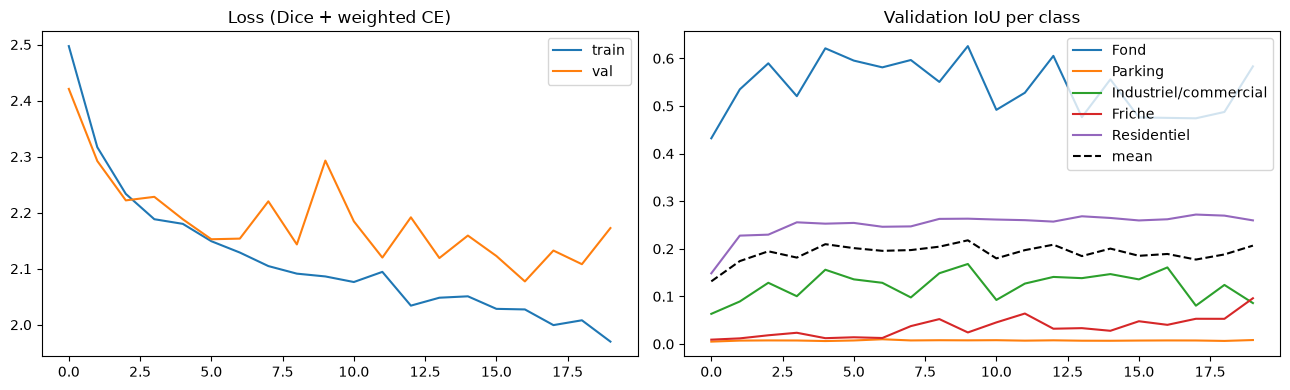

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss (Dice + weighted CE)")
axes[0].legend()

iou_per_class = list(zip(*history["val_iou_per_class"]))  # -> one series per class
for name, series in zip(CLASS_NAMES, iou_per_class):
    axes[1].plot(series, label=name)
axes[1].plot(history["val_mean_iou"], label="mean", linestyle="--", color="black")
axes[1].set_title("Validation IoU per class")
axes[1].legend()
plt.tight_layout()
plt.show()

### 7/ Test set evaluation

(Un essai a brièvement élargi la définition de Parking aux masques d'entraînement -- toute
taille, pas seulement >=1500m² -- pour donner plus de signal à la classe la plus rare.
Mesuré et annulé : les résultats étaient pires sur toutes les classes, y compris Parking
lui-même à définition égale. Voir docs/roadmap_segmentation.md §8, item 9.)

In [10]:
test_loss, test_iou = engine.eval_epoch(model, test_loader)
print(f"Test loss: {test_loss:.4f}\n")
print(f"{'Classe':<25}{'IoU':>8}")
for name, iou in zip(CLASS_NAMES, test_iou.tolist()):
    print(f"{name:<25}{iou:>8.4f}")

Test loss: 2.1314

Classe                        IoU
Fond                       0.6305
Parking                    0.0061
Industriel/commercial      0.2574
Friche                     0.0243
Residentiel                0.2938


### 8/ Visualize a few predictions

Image | ground-truth mask (colorized) | predicted mask (colorized), side by side, on test tiles.

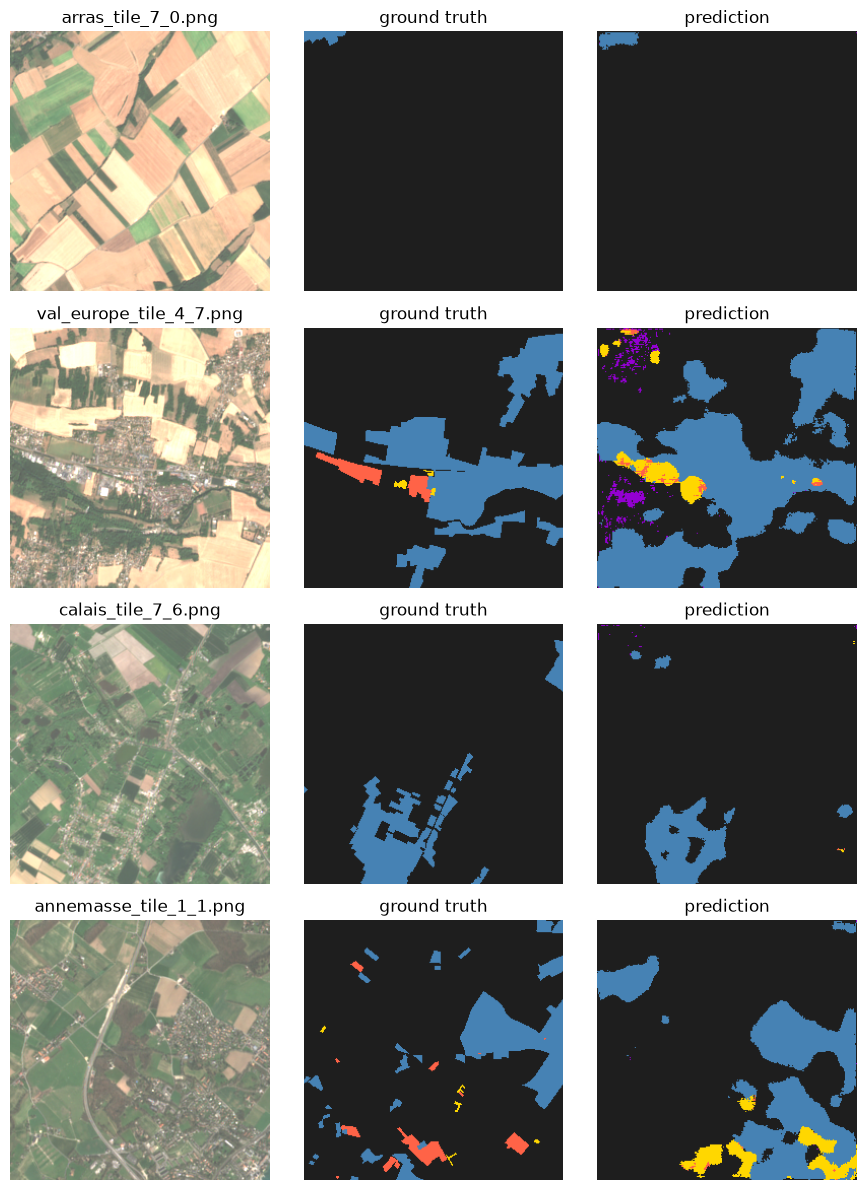

In [19]:
import random

from PIL import Image

MASKS_PREVIEW_DIR = DATA_DIR / "masks_preview"

sample_indices = random.sample(range(len(test_subset)), k=min(4, len(test_subset)))

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(9, 3 * len(sample_indices)))
model.eval()
with torch.no_grad():
    for row, local_idx in enumerate(sample_indices):
        dataset_idx = test_subset.indices[local_idx]
        name = full_dataset.filenames[dataset_idx]

        image_tensor, _ = test_subset[local_idx]
        pred = model(image_tensor.unsqueeze(0).to(device)).argmax(1).squeeze(0).cpu().numpy()

        axes[row, 0].imshow(Image.open(DATA_DIR / "images" / name))
        axes[row, 0].set_title(name)
        axes[row, 1].imshow(Image.open(MASKS_PREVIEW_DIR / name))
        axes[row, 1].set_title("ground truth")
        axes[row, 2].imshow(colorize_mask(pred))
        axes[row, 2].set_title("prediction")
        for ax in axes[row]:
            ax.axis("off")
plt.tight_layout()
plt.show()

### 9/ Save the trained weights

In [20]:
CHECKPOINT_DIR = Path.cwd().parent / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), CHECKPOINT_DIR / "unet_landuse.pth")
print(f"Saved checkpoint to {CHECKPOINT_DIR / 'unet_landuse.pth'}")

Saved checkpoint to /Users/erizzolio/Work/Alyra/SOLSCAN/checkpoints/unet_landuse.pth


### 10/ Validation croisée (GroupKFold par AOI)

Optionnel, séparé du pipeline ci-dessus -- donne une **moyenne ± écart-type** de l'IoU par
classe sur plusieurs folds au lieu du chiffre d'un seul split, ce qui compte ici vu le peu
de tuiles portant les classes rares (Parking, Friche) : un split malchanceux/chanceux peut
faire paraître une classe bien pire ou bien meilleure qu'elle ne l'est vraiment (voir la
variation de l'IoU Parking entre les deux runs ci-dessus : 0.028 -> 0.016 après l'ajout de
la classe résidentiel, sur exactement le même split 70/15/15 -- une partie de cet écart
pourrait n'être que du bruit de split sur une classe aussi rare).

Regroupe par AOI/ville (préfixe du nom de fichier avant `_tile_`), pas un K-fold aléatoire
classique -- les tuiles d'une même ville se ressemblent visuellement (même date
d'acquisition, même style de bâti), donc un split aléatoire laisserait fuiter cette
similarité entre train et val et surestimerait la généralisation à une zone réellement
nouvelle. Voir `helpers/dataloaders.build_group_kfold_dataloaders`.

**Coûteux** : entraîne un modèle neuf à chaque fold (`N_FOLDS` runs de `EPOCHS` epochs
chacun). À utiliser comme vérification ponctuelle de généralisation, pas comme boucle de
dev quotidienne -- les sections 1-9 ci-dessus (split unique) restent le chemin rapide pour
itérer.

In [ ]:
from helpers.dataloaders import build_group_kfold_dataloaders

N_FOLDS = 5

groups = [name.split("_tile_")[0] for name in full_dataset.filenames]
print(f"{len(set(groups))} AOI distinctes disponibles -- N_FOLDS={N_FOLDS}")

fold_ious = []  # un tensor iou_par_classe par fold

for fold_idx, cv_train_loader, cv_val_loader, cv_train_subset in build_group_kfold_dataloaders(
    full_dataset, groups, BATCH_SIZE, n_splits=N_FOLDS, seed=SEED_NUM, train_dataset=full_dataset_augmented
):
    fold_weights = compute_class_pixel_weights(cv_train_subset, num_classes=UNET_CONFIG.num_classes)

    fold_model = build_unet(num_classes=UNET_CONFIG.num_classes, device=device)
    fold_optimizer = torch.optim.Adam(fold_model.parameters(), lr=UNET_CONFIG.lr)
    fold_engine = SegEngine(device, fold_optimizer, num_classes=UNET_CONFIG.num_classes, class_weights=fold_weights)

    print(f"\n=== Fold {fold_idx + 1}/{N_FOLDS} -- train={len(cv_train_subset)} tuiles, val={len(cv_val_loader.dataset)} tuiles ===")
    fold_engine.train_model(fold_model, cv_train_loader, cv_val_loader, EPOCHS, class_names=CLASS_NAMES, patience=PATIENCE)

    # Meme logique que la section 5bis : on evalue avec les poids du meilleur epoch du fold,
    # pas ceux de la derniere epoch (overfitting).
    fold_model.load_state_dict(fold_engine.best_state_dict)
    _, val_iou = fold_engine.eval_epoch(fold_model, cv_val_loader)
    fold_ious.append(val_iou)

In [ ]:
import numpy as np

iou_matrix = torch.stack(fold_ious).numpy()  # (N_FOLDS, num_classes) -- NaN si un fold n'avait aucun pixel de cette classe en val
mean_iou = np.nanmean(iou_matrix, axis=0)
std_iou = np.nanstd(iou_matrix, axis=0)
n_folds_present = (~np.isnan(iou_matrix)).sum(axis=0)  # nombre de folds où la classe était présente en val

print(f"{'Classe':<25}{'IoU moyen':>12}{'Ecart-type':>14}{'Folds':>10}")
for name, m, s, n in zip(CLASS_NAMES, mean_iou, std_iou, n_folds_present):
    print(f"{name:<25}{m:>12.4f}{s:>14.4f}{n:>7d}/{N_FOLDS}")